# Business question

> Which geographic areas and property types contain the highest concentration of overpriced or underpriced listings relative to their estimated market value, and how can Airbnb leverage these pricing discrepancies to optimise host revenue strategies?

# Notebook execution guidelines

A kaggle username and its PAT is needed to retrieve the data, get yours from https://www.kaggle.com/settings/api then generate a "Legacy API Credentials".
This data goes within the `.env` file.

Before running this notebook, initialize a virtual environment and install requirements:
1. `python -m venv .venv`: to create the virtual environment.
2. `.venv\scripts\activate`: to activate the virtual environment using Windows.
3. `pip install -r requirements.txt`: to install the list of requirements.

In [79]:
import kaggle
import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

load_dotenv()
datasets_path = Path("dataset")

Download and read file (requires Kaggle account):

In [80]:
if not (datasets_path / "AB_NYC_2019.csv").exists():
    kaggle.api.dataset_download_files(
        "dgomonov/new-york-city-airbnb-open-data", path=datasets_path, unzip=True
    )
df_airbnb = pd.read_csv(datasets_path / "AB_NYC_2019.csv")

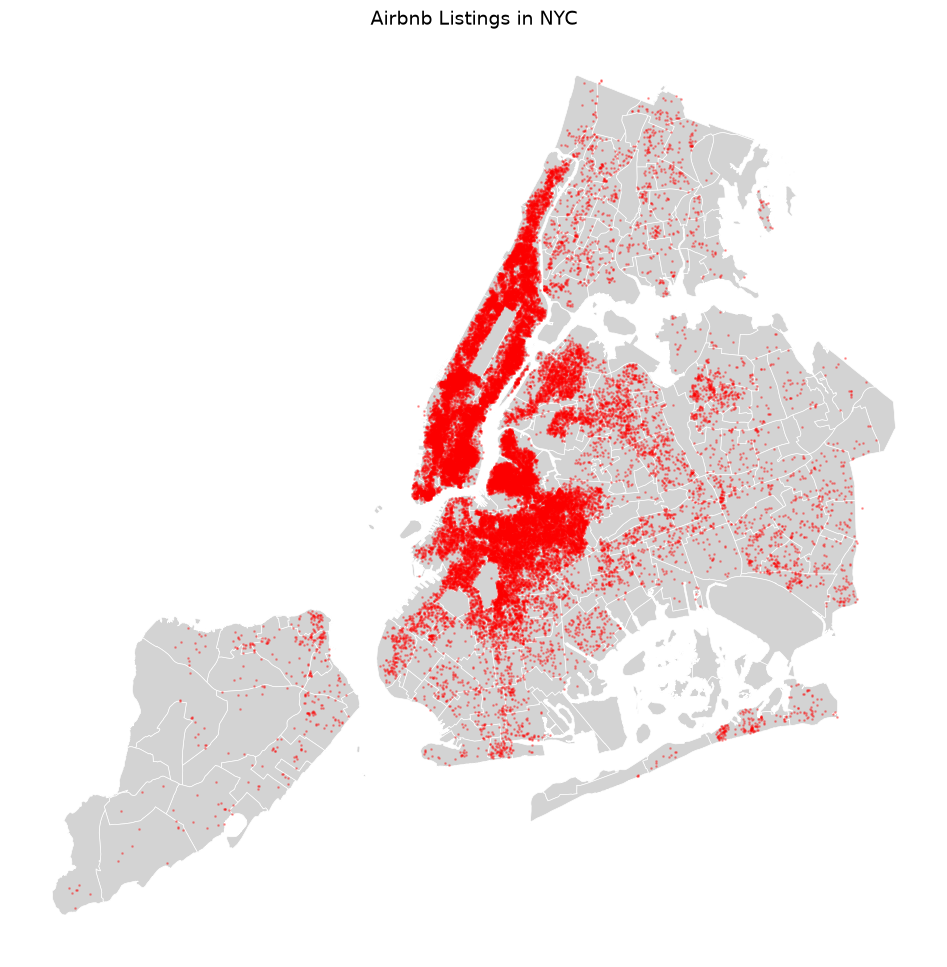

In [27]:
# City of New York: 2020 Neighborhood Tabulation Areas (NTAs) - Mapped
# https://data.cityofnewyork.us/City-Government/2020-Neighborhood-Tabulation-Areas-NTAs-Mapped/4hft-v355
url = "https://data.cityofnewyork.us/resource/9nt8-h7nd.geojson"
nyc_geojson = gpd.read_file(url)

# convert airbnb dataframe to geodataframe
gdf_airbnb = gpd.GeoDataFrame(
    df_airbnb,
    geometry=gpd.points_from_xy(df_airbnb.longitude, df_airbnb.latitude),
    crs="EPSG:4326",
)
nyc_geojson = nyc_geojson.to_crs("EPSG:4326")  # ensure same coordinate reference system
airbnb_enriched = gpd.sjoin(
    gdf_airbnb,
    nyc_geojson[["ntaname", "boroname", "geometry"]],
    how="left",
    predicate="within",
)  # assign neighborhoods and boroughs to airbnb listings

fig, ax = plt.subplots(figsize=(12, 12))
nyc_geojson.plot(
    ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5
)  # draw base map of NYC neighborhoods
airbnb_enriched.plot(
    ax=ax, color="red", markersize=1, alpha=0.3
)  # Overlay airbnb listings on top of the NYC map
ax.set_title("Airbnb Listings in NYC", fontsize=14)
ax.set_axis_off()

plt.show()

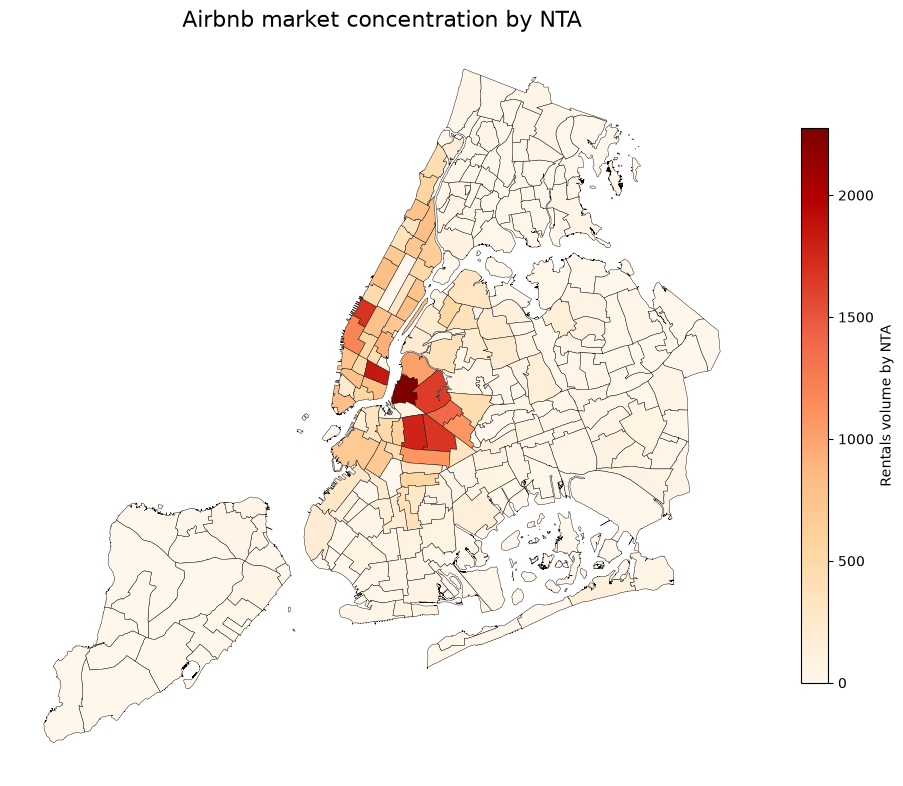

In [81]:
count_neighborhoods = airbnb_enriched["ntaname"].value_counts().reset_index()
count_neighborhoods.columns = ["ntaname", "total_listings"]

density_map = nyc_geojson.merge(
    count_neighborhoods, on="ntaname", how="left"
)  # join the counts with the GeoDataFrame to prepare for choropleth mapping

density_map["total_listings"] = density_map["total_listings"].fillna(
    0
)  # fill NaN values with 0 for neighborhoods with no listings
fig, ax = plt.subplots(figsize=(12, 12))

density_map.plot(
    column="total_listings",
    cmap="OrRd",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    legend_kwds={"shrink": 0.6, "label": "Rentals volume by NTA"},
    ax=ax,
)

ax.set_title("Airbnb market concentration by NTA", fontsize=16)
ax.set_axis_off()

plt.show()

# Data Preparation

## Data analysis
Explore how data is composed, then cleanup for ML modeling.

## Data cleaning
1. Remove null and missing values
2. Remove outliers
3. One-Hot Encoding for critical variables
4. Standardise geospatial data

In [82]:
print("The field name of data: ", df_airbnb.columns)  # The field name of data
print("Number of fields in data: ", len(df_airbnb.columns))  # Number of fields in data
print("Number of data in data: ", len(df_airbnb))  # Number of data in data

print(df_airbnb.info)
display(df_airbnb.head(10))

The field name of data:  Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')
Number of fields in data:  16
Number of data in data:  48895
<bound method DataFrame.info of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  364846

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [83]:
df_clean = airbnb_enriched.copy()
df_clean = df_clean.dropna(
    subset=["ntaname"]
)  # drop rows where 'ntaname' is NaN, which indicates listings outside of NYC boundaries
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(
    0
)  # fill NaN values in 'reviews_per_month' with 0, indicating no reviews for those listings

# removing outliers
max_price = df_clean["price"].quantile(
    0.99
)  # price 0 is an error, removing the top 1% of prices to avoid skewing the model
df_clean = df_clean[(df_clean["price"] > 0) & (df_clean["price"] <= max_price)]
df_clean = df_clean[
    df_clean["minimum_nights"] <= 365
]  # minimum_nights greater than 365 are likely errors or special cases, so we filter them out

# remove unnecesary columns for ML
ml_columns = [
    "ntaname",
    "boroname",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]
df_ml = df_clean[ml_columns].copy()
df_ml["log_price"] = np.log1p(
    df_ml["price"]
)  # log1p is used to avoid issues with log(0) and to handle the skewness of the price distribution

# Export
df_ml.to_csv(datasets_path / "airbnb_nyc_ml_base.csv", index=False)
df_ml.info()

<class 'pandas.DataFrame'>
Index: 48383 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ntaname                         48383 non-null  str    
 1   boroname                        48383 non-null  str    
 2   latitude                        48383 non-null  float64
 3   longitude                       48383 non-null  float64
 4   room_type                       48383 non-null  str    
 5   price                           48383 non-null  int64  
 6   minimum_nights                  48383 non-null  int64  
 7   number_of_reviews               48383 non-null  int64  
 8   reviews_per_month               48383 non-null  float64
 9   calculated_host_listings_count  48383 non-null  int64  
 10  availability_365                48383 non-null  int64  
 11  log_price                       48383 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 4.

# Enhance dataset
Adding distance to public transportation, and city tourist attractions. 

In [84]:
url_mta = "https://data.ny.gov/api/views/i9wp-a4ja/rows.csv?accessType=DOWNLOAD"
df_mta = pd.read_csv(url_mta)
col_lat_mta = (
    "Entrance Latitude" if "Entrance Latitude" in df_mta.columns else "Latitude"
)
col_lon_mta = (
    "Entrance Longitude" if "Entrance Longitude" in df_mta.columns else "Longitude"
)
df_mta = df_mta.dropna(subset=[col_lat_mta, col_lon_mta])
airbnb_coords = np.radians(
    df_ml[["latitude", "longitude"]].values
)  # convert coordiantes to radians
mta_coords = np.radians(
    df_mta[[col_lat_mta, col_lon_mta]].values
)  # convert coordiantes to radians
tree = BallTree(
    mta_coords, metric="haversine"
)  # create space tree based on subway stations
distances_rad, indices = tree.query(
    airbnb_coords, k=1
)  # Find nearest station for each airbnb listing
df_ml["dist_meters_to_subway"] = (
    distances_rad.flatten() * 6371000
)  # Convert radians to meters

# Check
print(df_ml[["latitude", "longitude", "dist_meters_to_subway"]].head())

   latitude  longitude  dist_meters_to_subway
0  40.64749  -73.97237             392.684521
1  40.75362  -73.98377              82.204337
2  40.80902  -73.94190             306.989382
3  40.68514  -73.95976             404.968892
4  40.79851  -73.94399             177.048398


In [86]:
# adding points of interest: we considered "https://data.cityofnewyork.us/City-Government/CommonPlace/rxuy-2muj" but has too many points
# we are going with strategic points of interest that are relevant to tourists and visitors of NYC
pois = [
    ("Times Square", 40.7580, -73.9855),
    ("Central Park", 40.7644, -73.9730),
    ("Met Museum", 40.7794, -73.9632),
    ("Empire State", 40.7484, -73.9857),
    ("Washington Square", 40.7308, -73.9973),
    ("SoHo", 40.7233, -73.9988),
    ("Financial District", 40.7074, -74.0113),
    ("Penn Station", 40.7505, -73.9934),
    ("Grand Central", 40.7527, -73.9772),
    ("Williamsburg", 40.7160, -73.9587),
    ("Barclays Center", 40.6826, -73.9754),
    ("Long Island City", 40.7465, -73.9455),
]
poi_coords = np.radians([[lat, lon] for _, lat, lon in pois])
airbnb_coords = np.radians(df_ml[["latitude", "longitude"]].values)
tree_poi = BallTree(poi_coords, metric="haversine")
dist_rad, _ = tree_poi.query(airbnb_coords, k=1)
df_ml["dist_min_poi_meters"] = dist_rad.flatten() * 6371000

print(df_ml[["latitude", "longitude", "dist_min_poi_meters"]].head())

   latitude  longitude  dist_min_poi_meters
0  40.64749  -73.97237          3912.409764
1  40.75362  -73.98377           508.365635
2  40.80902  -73.94190          3750.044474
3  40.68514  -73.95976          1348.686632
4  40.79851  -73.94399          2670.365539


# Clustering Analysis

The purpose of this clustering analysis is to group Airbnb listings with similar characteristics.  
This helps identify different market segments, such as budget listings, premium listings, highly available listings, and listings close to tourist attractions or public transport.

In [87]:
clustering_features = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "dist_meters_to_subway",
    "dist_min_poi_meters"
]

df_cluster = df_ml[clustering_features].copy()
df_cluster.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,dist_meters_to_subway,dist_min_poi_meters
0,149,1,9,0.21,6,365,392.684521,3912.409764
1,225,1,45,0.38,2,355,82.204337,508.365635
2,150,3,0,0.00,1,365,306.989382,3750.044474
3,89,1,270,4.64,1,194,404.968892,1348.686632
4,80,10,9,0.10,1,0,177.048398,2670.365539


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale the clustering features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_cluster)

# Apply PCA for visualization
pca = PCA(n_components=2, random_state=11)
pca_components = pca.fit_transform(X_cluster_scaled)

# Add PCA components to df_ml for visualization
df_ml["pca_1"] = pca_components[:, 0]
df_ml["pca_2"] = pca_components[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

In [88]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=11,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    
    # Use a sample for silhouette score to avoid very long runtime
    score = silhouette_score(
        X_cluster_scaled,
        labels,
        sample_size=5000,
        random_state=11
    )
    
    silhouette_scores.append(score)

The silhouette score was calculated using a random sample of 5,000 listings because the full dataset contains many Airbnb listings and silhouette scoring is computationally expensive on large datasets. Sampling provides an efficient approximation while still allowing comparison between different numbers of clusters.

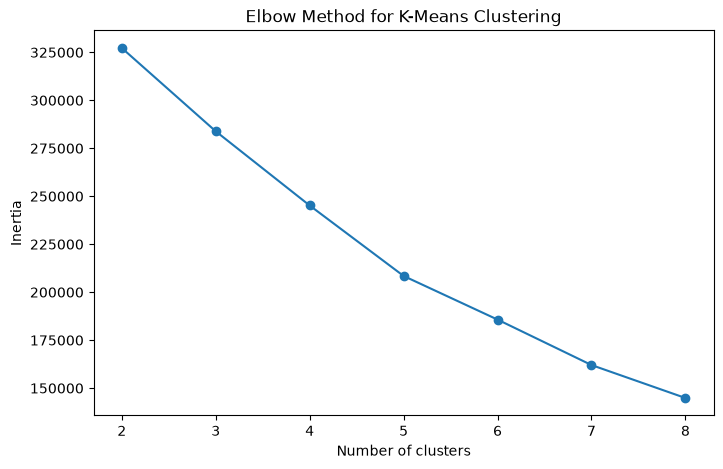

In [89]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.show()

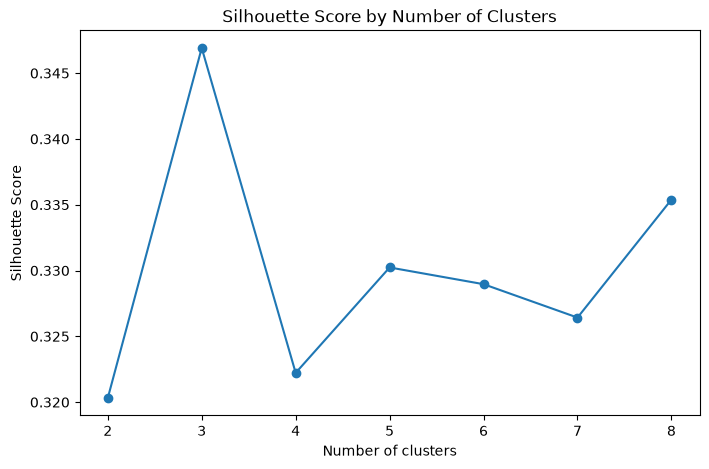

In [90]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

The Elbow Method did not show a very sharp turning point, although the reduction in inertia became more gradual after approximately 3–5 clusters. The Silhouette Score reached its highest value at k=3, indicating that three clusters produced the best separation among the tested values. Therefore, k=3 was selected for the final K-Means clustering model.

In [91]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=11,
    n_init=10
)

df_ml["cluster"] = kmeans.fit_predict(X_cluster_scaled)

df_ml[["price", "room_type", "boroname", "cluster"]].head()

,price,room_type,boroname,cluster
0,149,Private room,Brooklyn,0
1,225,Entire home/apt,Manhattan,0
2,150,Private room,Manhattan,0
3,89,Entire home/apt,Brooklyn,1
4,80,Entire home/apt,Manhattan,0


In [92]:
cluster_profile = df_ml.groupby("cluster")[clustering_features].mean().round(2)

cluster_sizes = df_ml["cluster"].value_counts().sort_index()

cluster_summary = cluster_profile.copy()
cluster_summary["number_of_listings"] = cluster_sizes

cluster_summary

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,dist_meters_to_subway,dist_min_poi_meters,number_of_listings
cluster,,,,,,,,,
0,141.90,6.48,9.08,0.52,2.75,83.99,300.68,2451.12,36227
1,112.04,2.70,74.11,3.13,2.34,185.63,716.94,5783.17,10802
2,225.47,47.48,2.87,0.38,164.45,275.07,240.13,1050.20,1354


In [93]:
room_type_distribution = pd.crosstab(
    df_ml["cluster"],
    df_ml["room_type"],
    normalize="index"
).round(2)

room_type_distribution

room_type,Entire home/apt,Private room,Shared room
cluster,,,
0,0.52,0.45,0.02
1,0.45,0.52,0.03
2,0.88,0.11,0.00


In [94]:
borough_distribution = pd.crosstab(
    df_ml["cluster"],
    df_ml["boroname"],
    normalize="index"
).round(2)

borough_distribution

boroname,Bronx,Brooklyn,Manhattan,Queens,Staten Island
cluster,,,,,
0,0.01,0.43,0.47,0.08,0.00
1,0.06,0.39,0.28,0.24,0.03
2,0.00,0.04,0.90,0.06,0.00


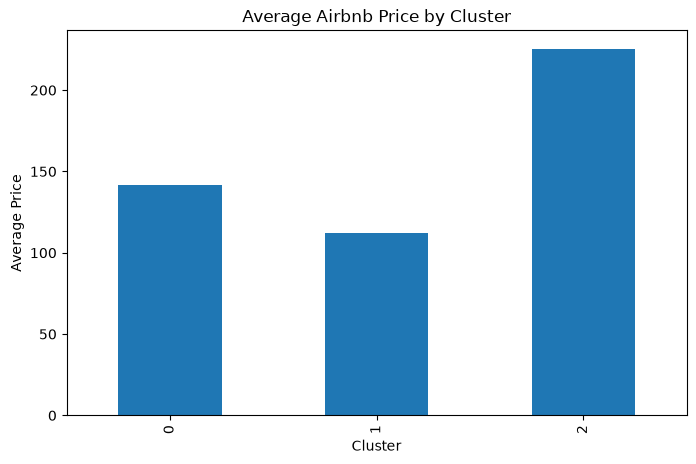

In [95]:
cluster_summary["price"].plot(kind="bar", figsize=(8, 5))

plt.xlabel("Cluster")
plt.ylabel("Average Price")
plt.title("Average Airbnb Price by Cluster")
plt.show()

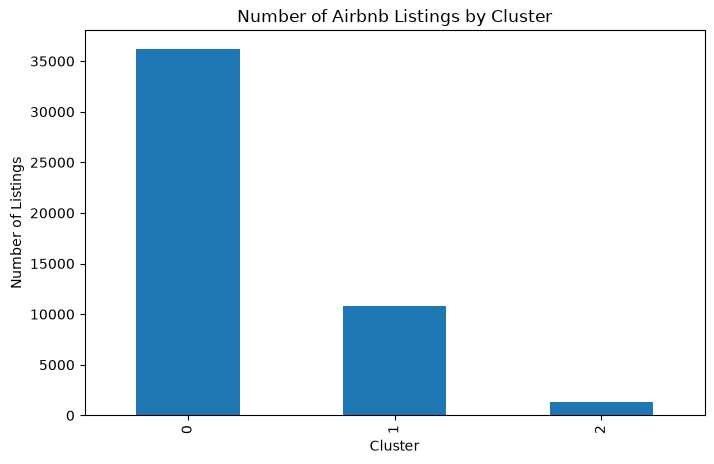

In [96]:
cluster_summary["number_of_listings"].plot(kind="bar", figsize=(8, 5))

plt.xlabel("Cluster")
plt.ylabel("Number of Listings")
plt.title("Number of Airbnb Listings by Cluster")
plt.show()

In [99]:
cluster_colors = {
    0: "#0072B2",  # blue
    1: "#000000",  # black
    2: "#009E73",  # green
}

plt.figure(figsize=(8, 6))

for cluster in sorted(df_ml["cluster"].unique()):
    subset = df_ml[df_ml["cluster"] == cluster]
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        color=cluster_colors[cluster],
        label=f"Cluster {cluster}",
        alpha=0.5,
        s=10
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Airbnb Listing Clusters Visualized with PCA")
plt.legend()
plt.show()

KeyError: 'pca_1'

<Figure size 800x600 with 0 Axes>

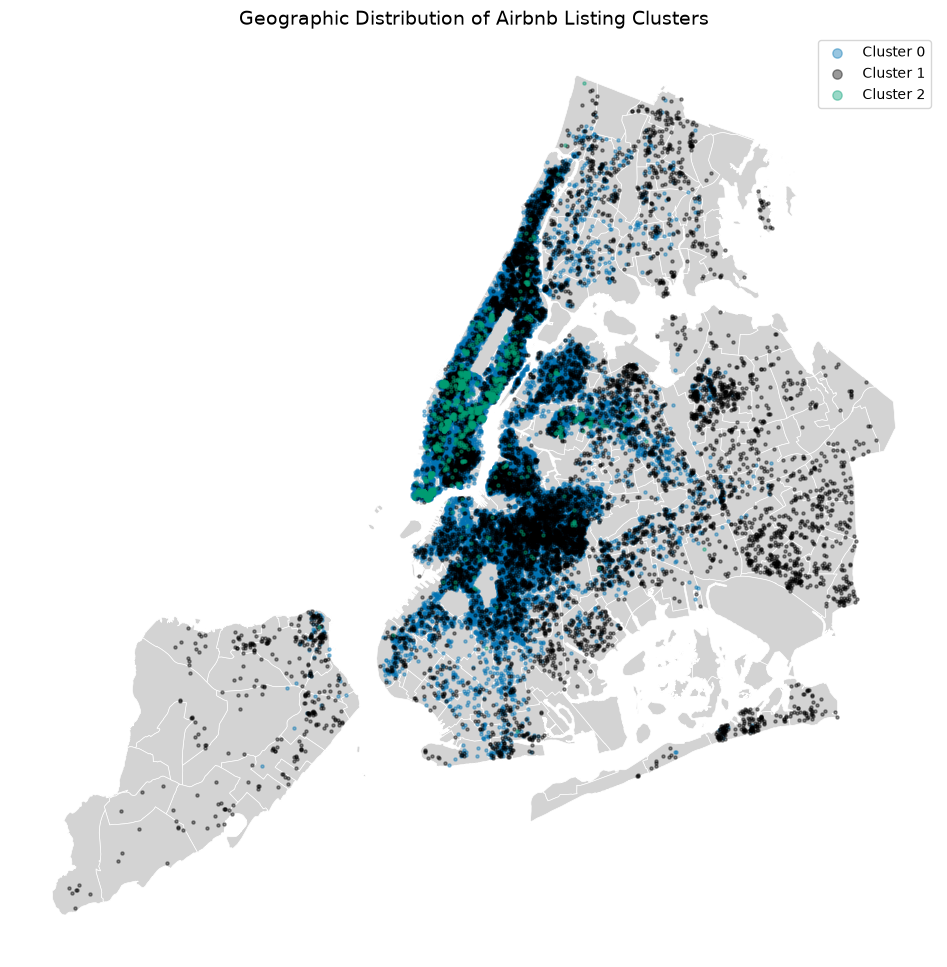

In [75]:
fig, ax = plt.subplots(figsize=(12, 12))

nyc_geojson.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5
)

for cluster in sorted(df_ml["cluster"].unique()):
    subset = df_ml[df_ml["cluster"] == cluster]
    ax.scatter(
        subset["longitude"],
        subset["latitude"],
        color=cluster_colors[cluster],
        s=5,
        alpha=0.4,
        label=f"Cluster {cluster}"
    )

ax.set_title("Geographic Distribution of Airbnb Listing Clusters", fontsize=14)
ax.set_axis_off()
ax.legend(loc="upper right", markerscale=3)

plt.show()

## Clustering Results and Interpretation

The final K-Means model was trained with `k=3`, based on the Elbow Method and Silhouette Score. The Elbow Method did not show a very sharp turning point, but the Silhouette Score reached its highest value at three clusters. Therefore, three clusters were selected as the most appropriate segmentation.

The clustering analysis identified three main Airbnb listing segments:

**Cluster 0: Mainstream Manhattan/Brooklyn listings**  
This was the largest cluster, containing 36,227 listings. It had a mid-range average price of approximately $141.90 and was mainly concentrated in Manhattan and Brooklyn. The room type distribution was balanced between entire homes/apartments and private rooms. This cluster appears to represent the mainstream Airbnb market in central NYC areas.

**Cluster 1: High-demand budget/value listings**  
This cluster contained 10,802 listings and had the lowest average price, approximately $112.04. However, it also had the highest review activity, with an average of 74.11 reviews and 3.13 reviews per month. This suggests that these listings may be more frequently booked or more attractive to price-sensitive guests. The cluster also had a higher share of listings in Queens, the Bronx and Staten Island compared with the other clusters.

**Cluster 2: Premium professional Manhattan listings**  
This was the smallest cluster, containing 1,354 listings, but it had the highest average price at approximately $225.47. It was strongly concentrated in Manhattan, where 90% of its listings were located. It also had the highest average minimum nights, host listing count and availability. Since 88% of listings in this cluster were entire homes/apartments and the average host managed many listings, this segment appears to represent premium, professionally managed Manhattan properties.

The PCA visualization shows that the three clusters form distinguishable groups, although there is some overlap between them. This is expected in real-world Airbnb data because listings can share similar characteristics across price, location, availability and review activity. The geographic map also shows that the clusters have spatial meaning: Cluster 0 is strongly represented in Manhattan and Brooklyn, Cluster 1 is more widely distributed across outer boroughs, and Cluster 2 is concentrated mainly in Manhattan.

Overall, the clustering analysis shows that the NYC Airbnb market can be divided into distinct segments based on price, review activity, availability, location and host behaviour. These clusters can support Airbnb's pricing strategy by showing which types of listings are more likely to behave like budget, mainstream or premium professional properties.

In [78]:
# Final encoding for ML - categorical variables to numbers
# we discard ntaname due high cardinality, we keep boroname as a proxy for aggregated location
df_final = pd.get_dummies(
    df_ml.drop(columns=["ntaname"]), columns=["room_type", "boroname"], drop_first=True
)

X = df_final.drop(columns=["price", "log_price"])
y = df_final["log_price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

# train baseline (random forest)
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=11)
model.fit(X_train, y_train)

# Initial evaluation
preds = model.predict(X_test)
print(f"R2 Score over base model: {r2_score(y_test, preds):.4f}")

# Analysis of variable importance to justify which variables are effective
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(
    ascending=False
)
print("\nVariable importance:")
print(importances)

# Export
df_final.to_csv(datasets_path / "airbnb_nyc_ml_final.csv", index=False)

ValueError: could not convert string to float: 'normal'

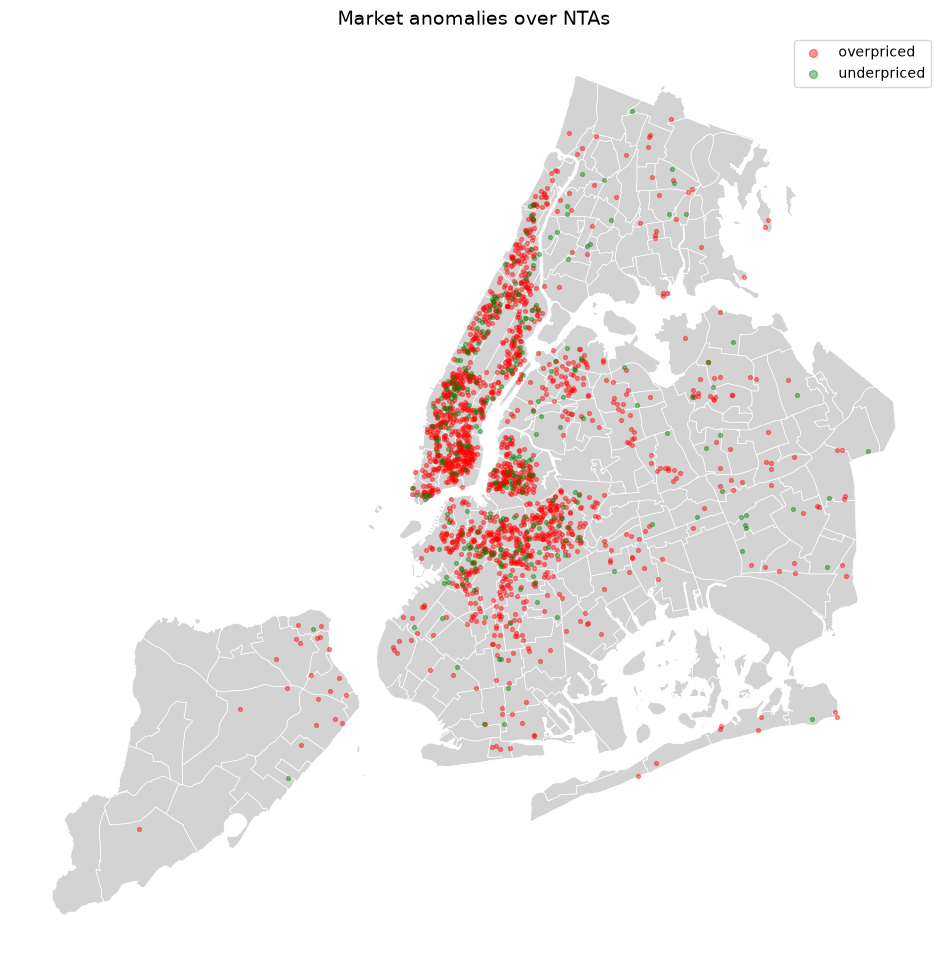

In [ ]:
# calculate predictions and anomalies (using expm1 because we trained with log1p)
df_ml["predicted_price"] = np.expm1(model.predict(X))
df_ml["residue_error"] = df_ml["price"] - df_ml["predicted_price"]

# identify anomalies: overpriced if real price > 50% of predicted, underpriced if real price < 50% of predicted
df_ml["status"] = "normal"
df_ml.loc[df_ml["residue_error"] > (df_ml["predicted_price"] * 0.5), "status"] = (
    "overpriced"
)
df_ml.loc[df_ml["residue_error"] < -(df_ml["predicted_price"] * 0.5), "status"] = (
    "underpriced"
)

# visual importance of business opportunity
fig, ax = plt.subplots(figsize=(12, 12))
nyc_geojson.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.5)

anomalies = df_ml[df_ml["status"] != "normal"]
colors = {"overpriced": "red", "underpriced": "green"}

for status, color in colors.items():
    subset = anomalies[anomalies["status"] == status]
    ax.scatter(
        subset["longitude"], subset["latitude"], c=color, s=8, label=status, alpha=0.4
    )

ax.set_title("Market anomalies over NTAs", fontsize=14)
ax.set_axis_off()
ax.legend(loc="upper right", markerscale=2)

plt.show()